In [21]:
import pickle
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Autoencoder, SirenNet
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import umap
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [2]:
resolution = 16

df = pd.read_csv("../data/freesolv.csv")

smiles = df["smiles"].tolist()

fd = FieldDataset(smiles, resolution=resolution)
dl = DataLoader(fd, batch_size=4, shuffle=True)
dl_test = DataLoader(fd, batch_size=8, shuffle=False)

In [3]:
net = SirenNet(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=4,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

autoencoder = Autoencoder(
    net,
    in_channels=10,
    output_shape=[resolution, resolution, resolution, 10, 1],
    latent_dim=512,
)

autoencoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=autoencoder.parameters())

# Load the model
autoencoder.load_state_dict(torch.load("../models/freesolv_b.pt", weights_only=True))
autoencoder.cuda()

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Autoencoder(
  (net): SirenNet(
    (layers): ModuleList(
      (0-3): 4 x Siren(
        (activation): Sine()
      )
    )
    (last_layer): Siren(
      (activation): Identity()
    )
  )
  (encoder): Encoder(
    (in_layer): Conv3d(10, 20, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_input): BatchNorm3d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (layer_1): Conv3d(20, 40, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_1): BatchNorm3d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (out_layer): Conv3d(40, 512, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_output): BatchNorm3d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pooling): AdaptiveAvgPool3d(output_size=1)
  )
  (modulator): Modulator(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): ReLU()
      )
      

yt : [INFO     ] 2025-02-11 18:03:46,706 Parameters: current_time              = 0.0                                  | 0/81 [00:00<?, ?it/s]
yt : [INFO     ] 2025-02-11 18:03:46,706 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 18:03:46,707 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:03:46,707 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:03:46,707 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:03:46,767 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:03:46,774 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:03:46,775 Creating volume
yt : [INFO     ] 2025-02-11 18:03:46,790 Creating transfer function
yt : [INFO     ] 2025-02-11 18:03:46,791 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


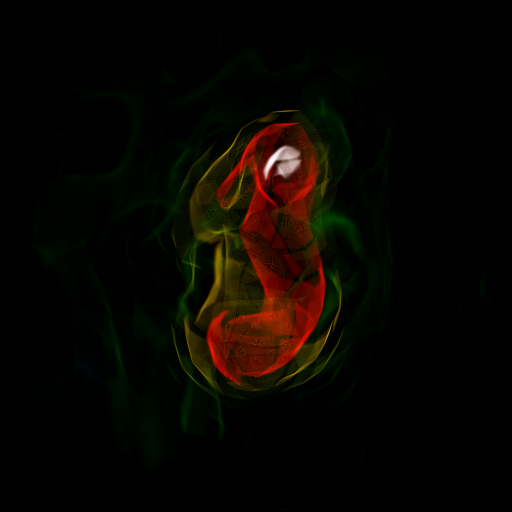

yt : [INFO     ] 2025-02-11 18:03:46,950 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:03:46,951 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 18:03:46,951 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:03:46,951 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:03:46,951 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:03:46,993 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:03:47,000 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:03:47,001 Creating volume
yt : [INFO     ] 2025-02-11 18:03:47,016 Creating transfer function
yt : [INFO     ] 2025-02-11 18:03:47,016 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


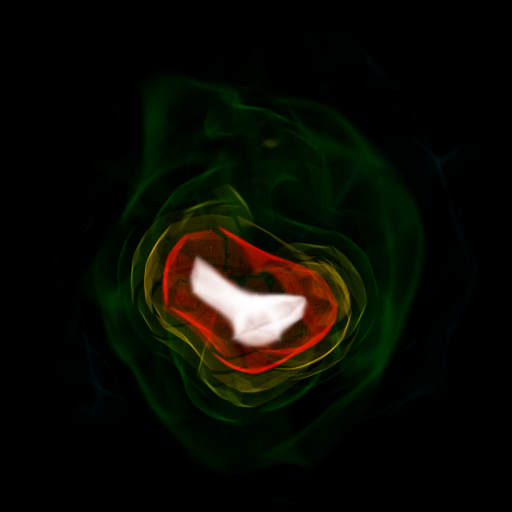

yt : [INFO     ] 2025-02-11 18:03:47,213 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:03:47,214 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 18:03:47,214 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:03:47,214 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:03:47,214 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:03:47,258 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:03:47,264 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:03:47,265 Creating volume
yt : [INFO     ] 2025-02-11 18:03:47,280 Creating transfer function
yt : [INFO     ] 2025-02-11 18:03:47,281 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


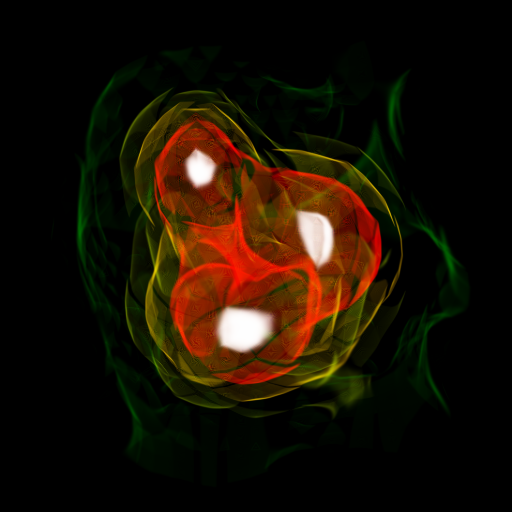

yt : [INFO     ] 2025-02-11 18:03:47,468 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:03:47,468 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 18:03:47,468 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:03:47,469 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:03:47,469 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:03:47,514 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:03:47,521 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:03:47,522 Creating volume
yt : [INFO     ] 2025-02-11 18:03:47,537 Creating transfer function
yt : [INFO     ] 2025-02-11 18:03:47,537 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


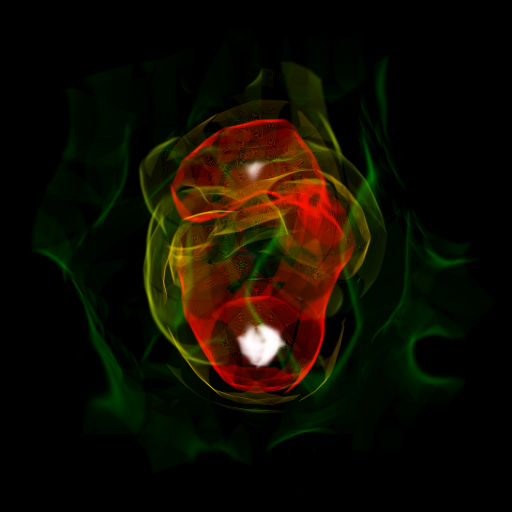

yt : [INFO     ] 2025-02-11 18:03:47,730 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:03:47,730 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 18:03:47,731 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:03:47,731 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:03:47,731 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:03:47,774 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:03:47,781 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:03:47,781 Creating volume
yt : [INFO     ] 2025-02-11 18:03:47,799 Creating transfer function
yt : [INFO     ] 2025-02-11 18:03:47,799 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


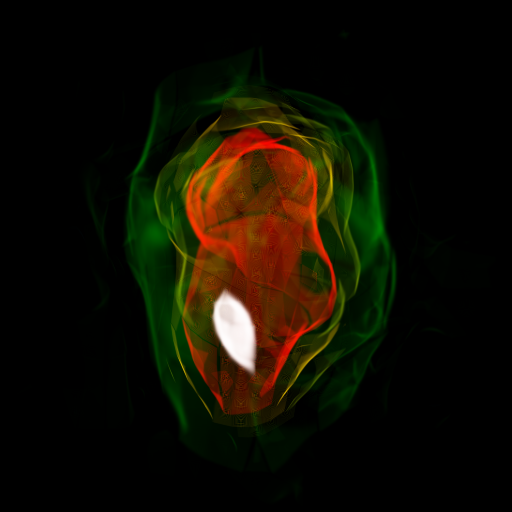

yt : [INFO     ] 2025-02-11 18:03:47,963 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:03:47,963 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 18:03:47,964 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:03:47,964 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:03:47,964 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:03:48,006 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:03:48,013 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:03:48,014 Creating volume
yt : [INFO     ] 2025-02-11 18:03:48,029 Creating transfer function
yt : [INFO     ] 2025-02-11 18:03:48,029 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


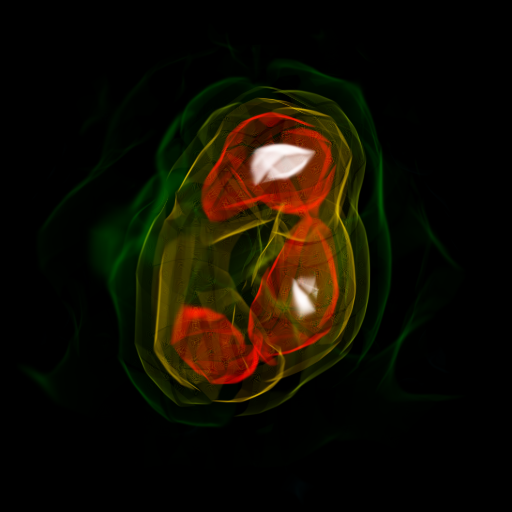

yt : [INFO     ] 2025-02-11 18:03:48,209 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:03:48,209 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 18:03:48,209 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:03:48,209 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:03:48,210 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:03:48,333 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:03:48,339 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:03:48,340 Creating volume
yt : [INFO     ] 2025-02-11 18:03:48,355 Creating transfer function
yt : [INFO     ] 2025-02-11 18:03:48,356 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


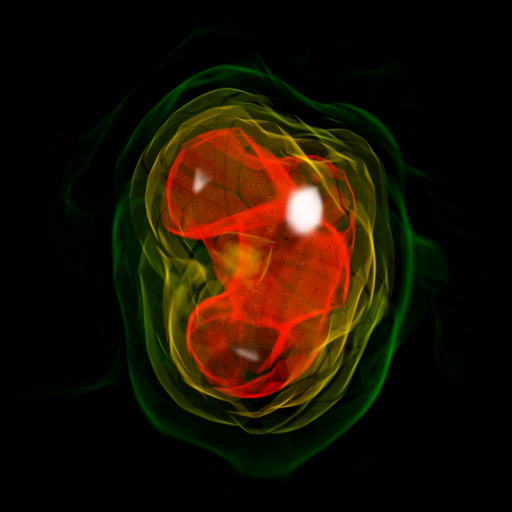

yt : [INFO     ] 2025-02-11 18:03:48,550 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 18:03:48,550 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 18:03:48,550 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 18:03:48,551 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 18:03:48,551 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 18:03:48,592 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 18:03:48,598 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 18:03:48,599 Creating volume
yt : [INFO     ] 2025-02-11 18:03:48,614 Creating transfer function
yt : [INFO     ] 2025-02-11 18:03:48,614 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


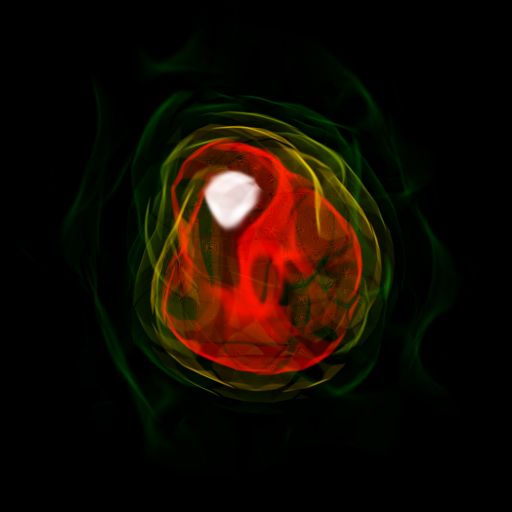

  0%|                                                                                                                 | 0/81 [00:02<?, ?it/s]


In [4]:
x = []
for batch in tqdm(dl_test, total=len(dl_test)):
    latents = autoencoder.encode(batch.cuda())
    predictions = autoencoder.predict(latents).cpu().detach().squeeze(-1)
    for pred in predictions:
        plot_field(pred[:, :, :, 0]).show()
    break

In [6]:
x = []
for batch in tqdm(dl_test, total=len(dl_test)):
    latents = autoencoder.encode(batch.cuda())
    for latent in latents:
        x.append(latent.cpu().detach().numpy())

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 81/81 [00:03<00:00, 25.66it/s]


In [37]:
y = df["freesolv"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1)
mlp = MLPRegressor(hidden_layer_sizes=(512,64,32), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2 Score: {r2}')

Root Mean Squared Error: 2.5752013767530335
R^2 Score: 0.32729449809056854


/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


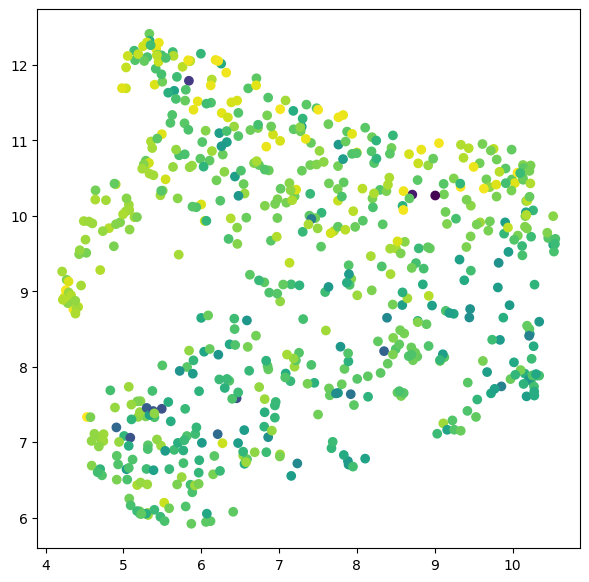

0


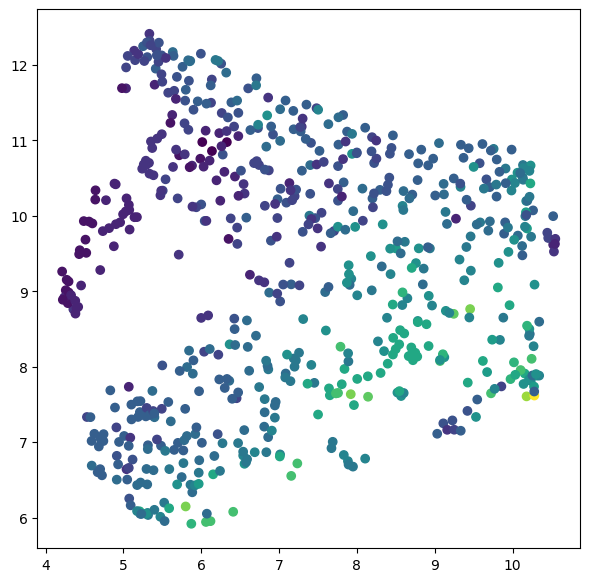

1


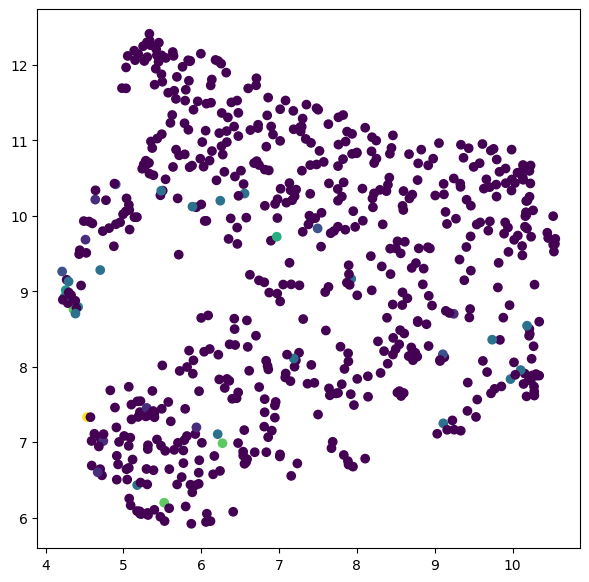

2


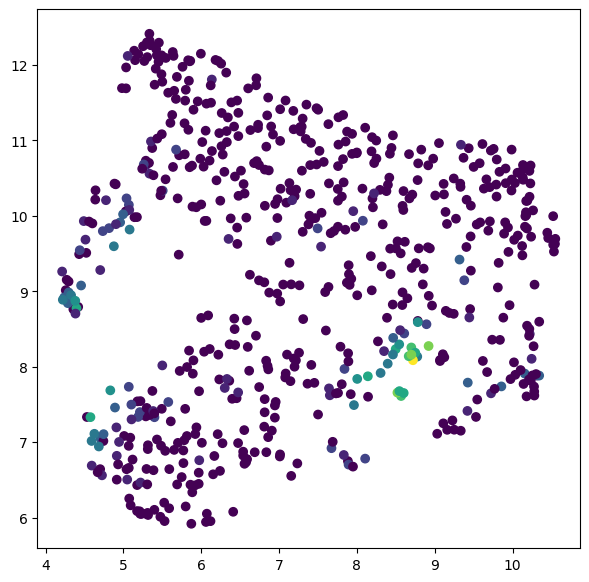

3


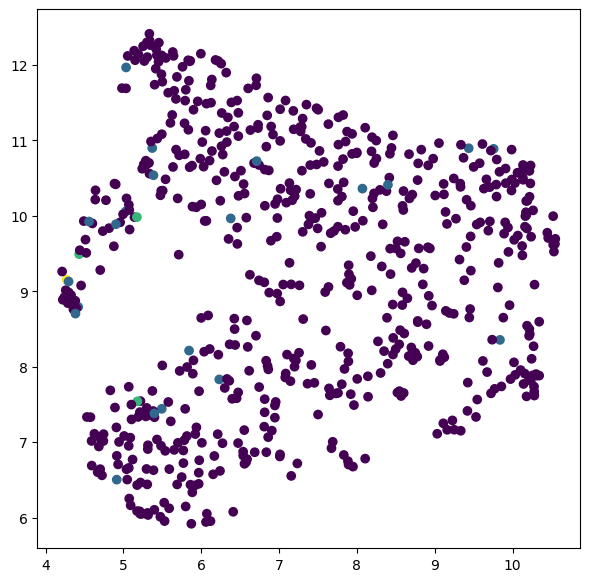

4


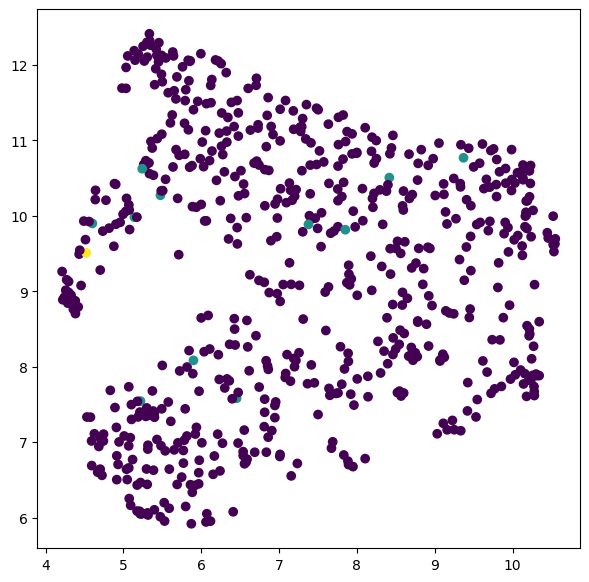

5


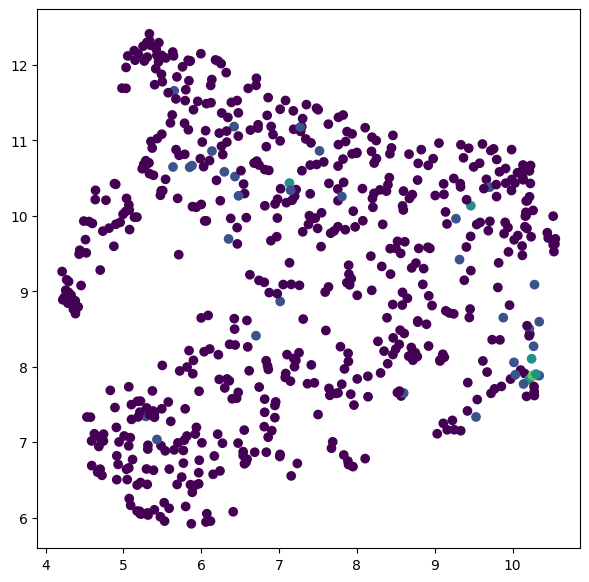

6


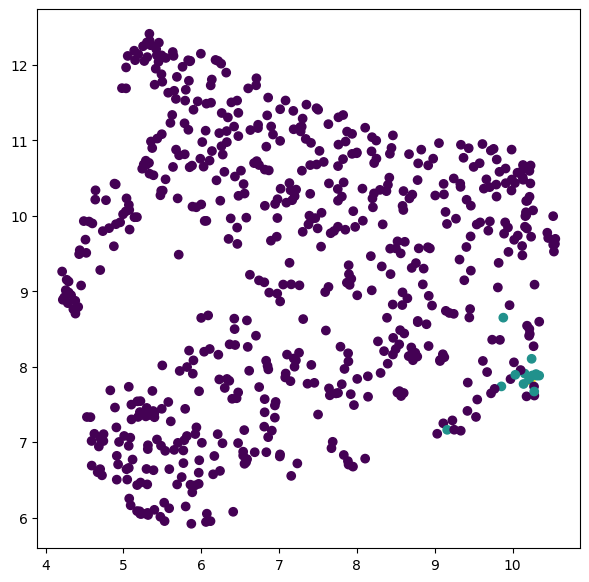

7


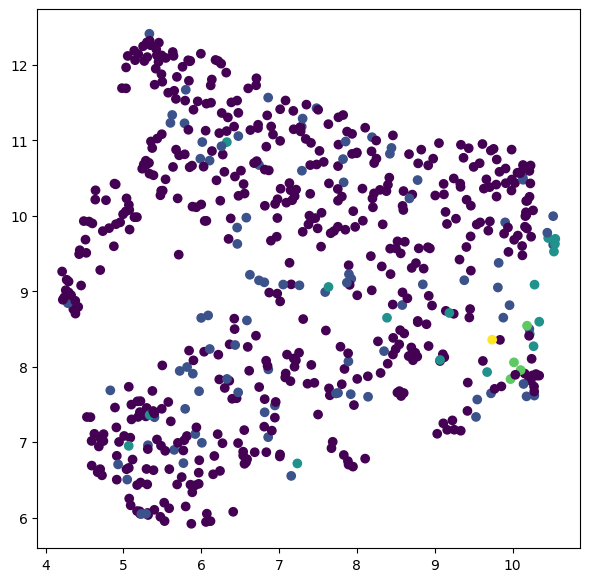

8


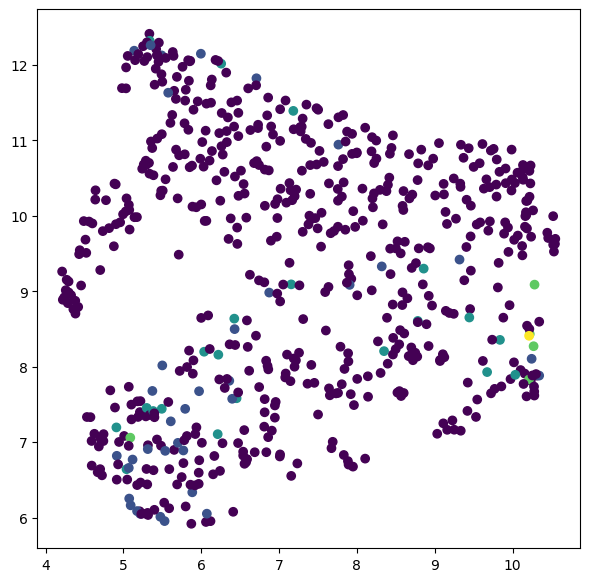

9


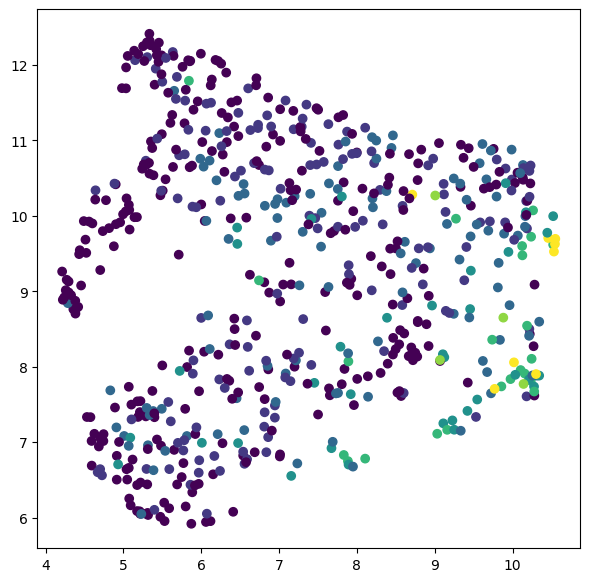

10


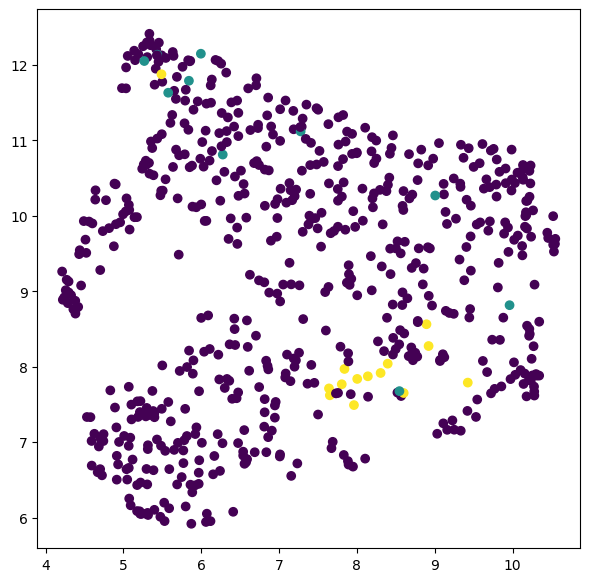

11


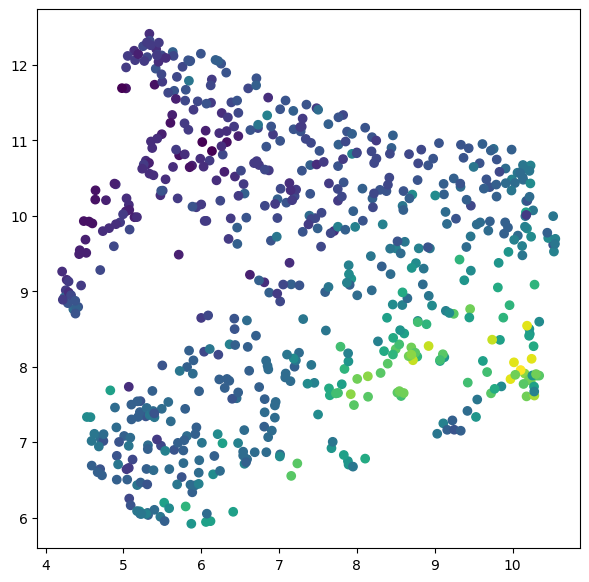

12


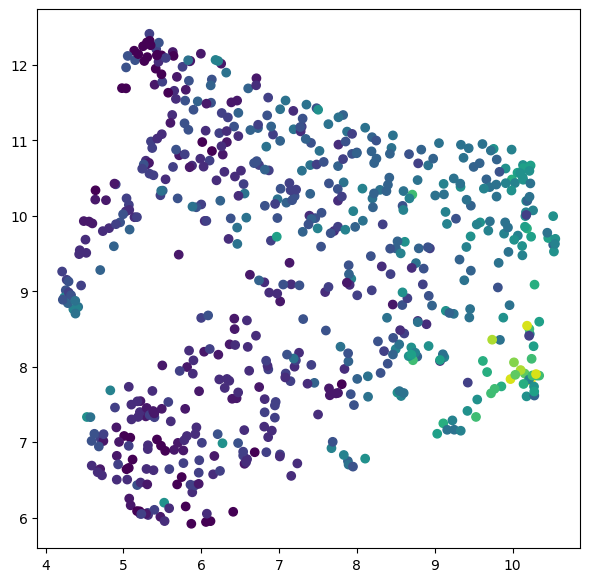

13


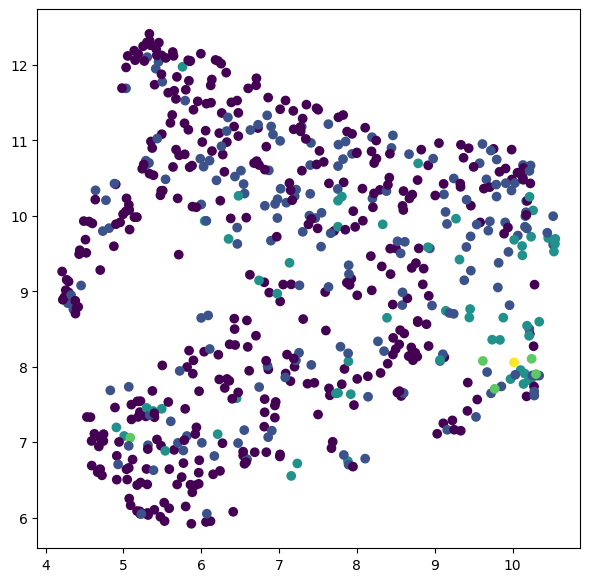

14


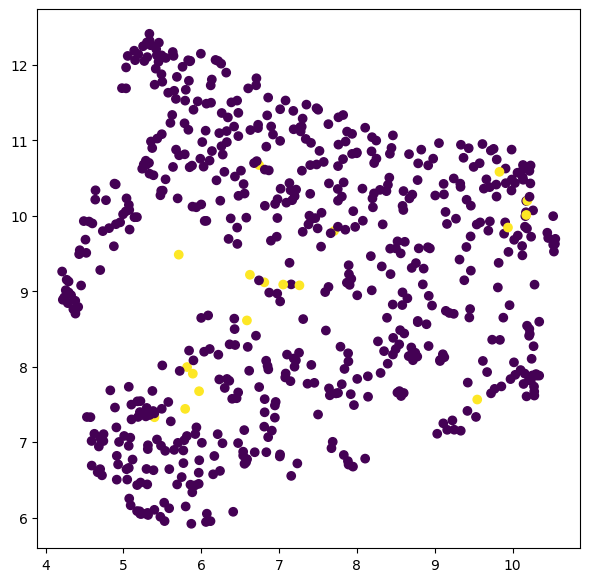

15


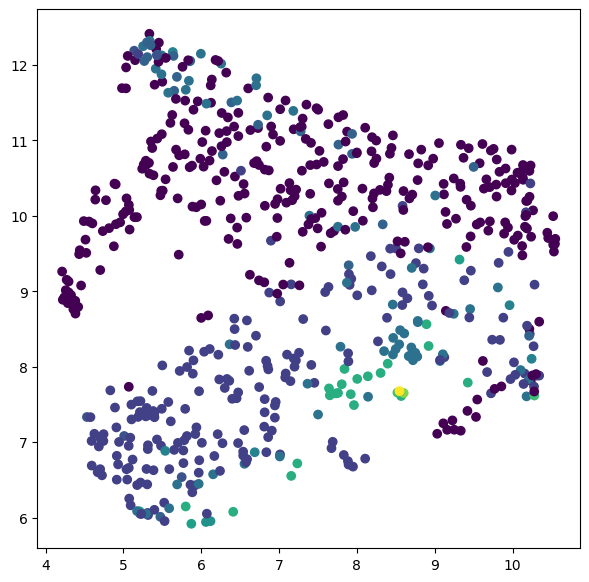

16


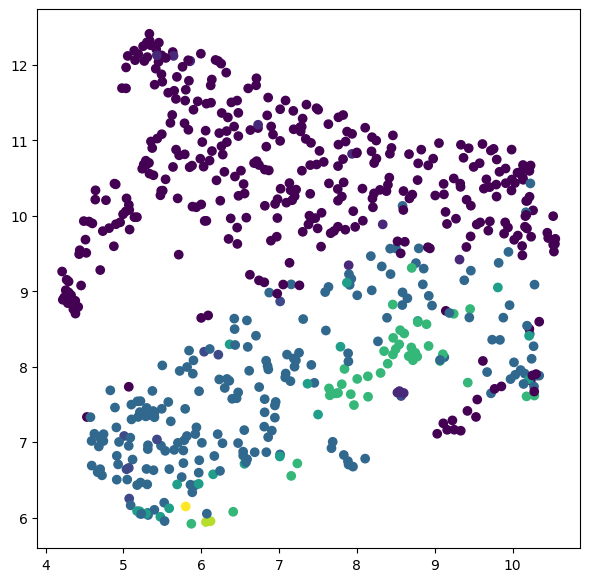

17


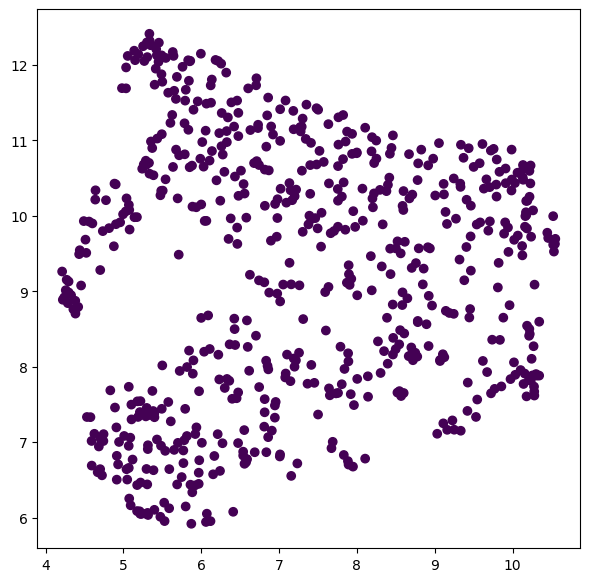

18


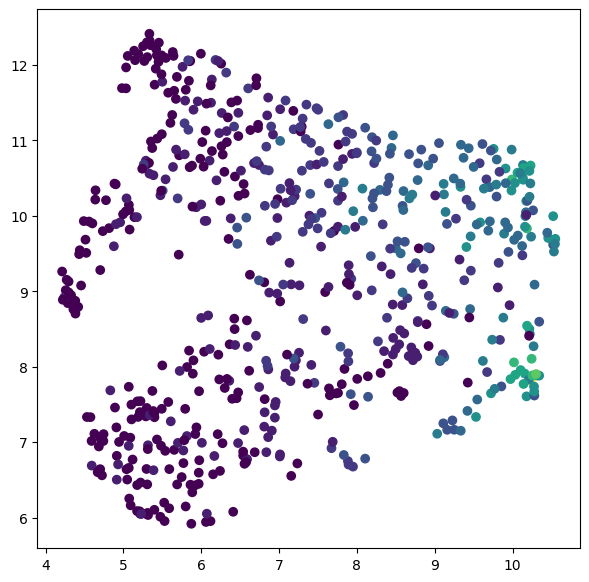

19


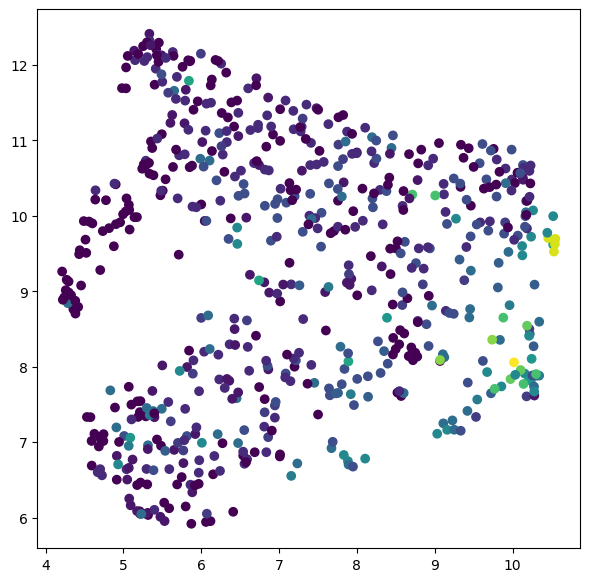

20


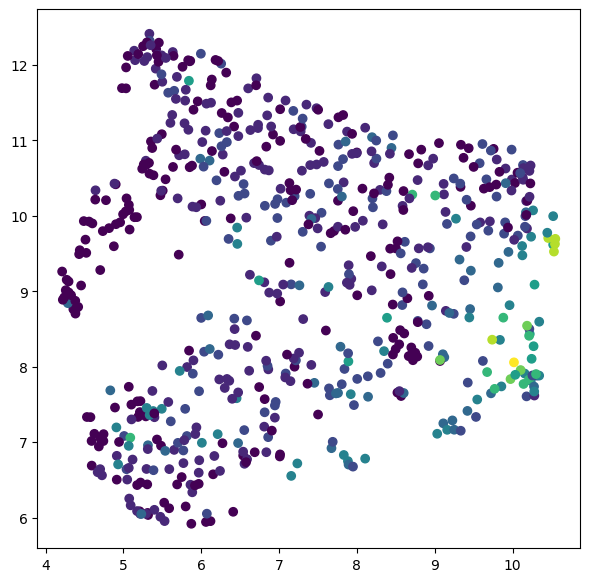

21


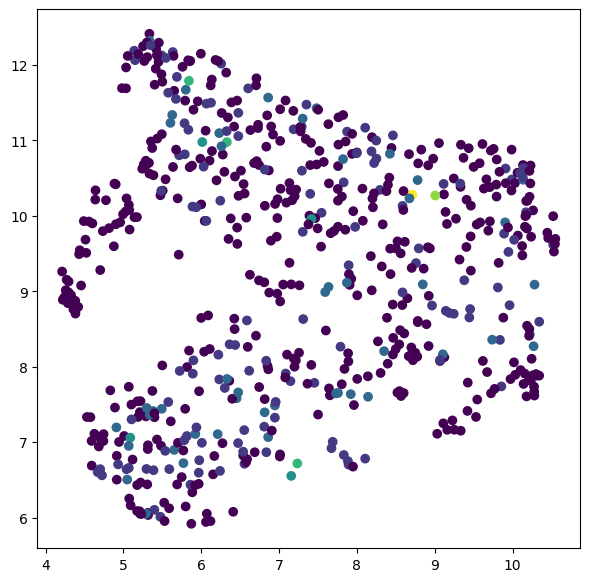

22


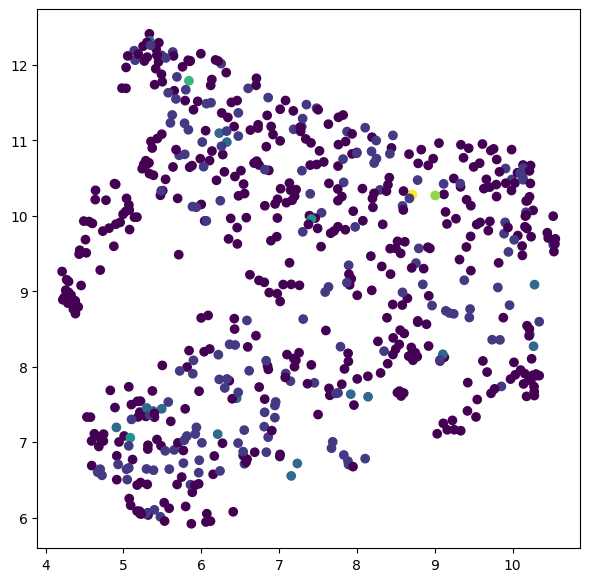

23


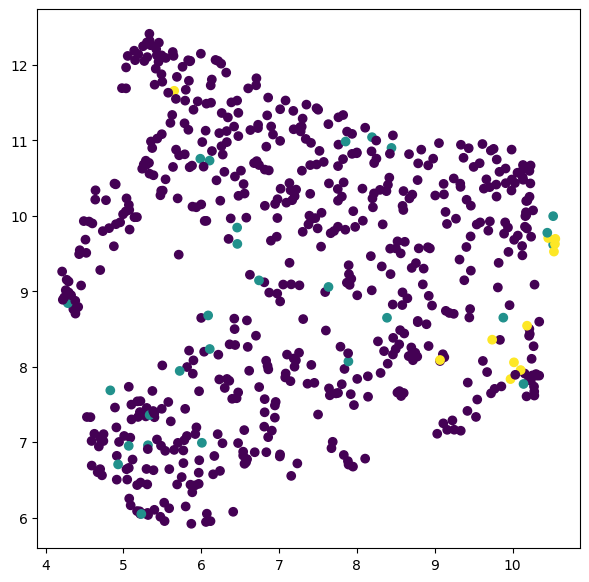

24


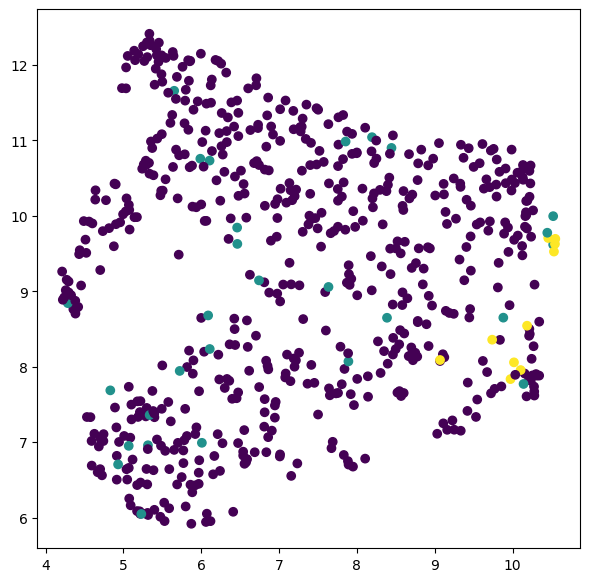

25


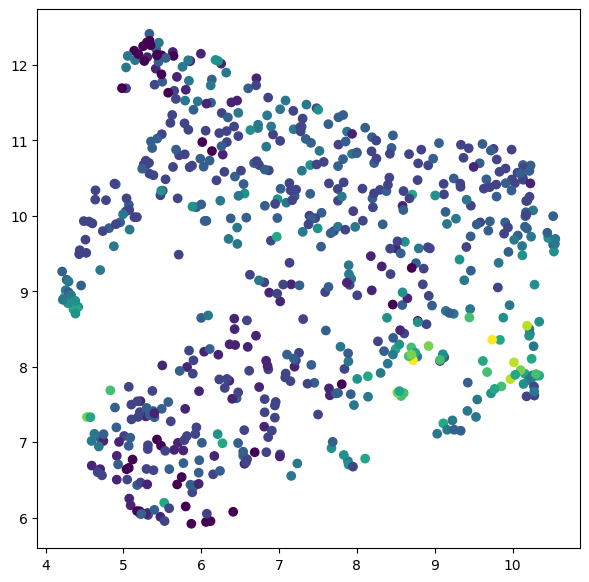

26


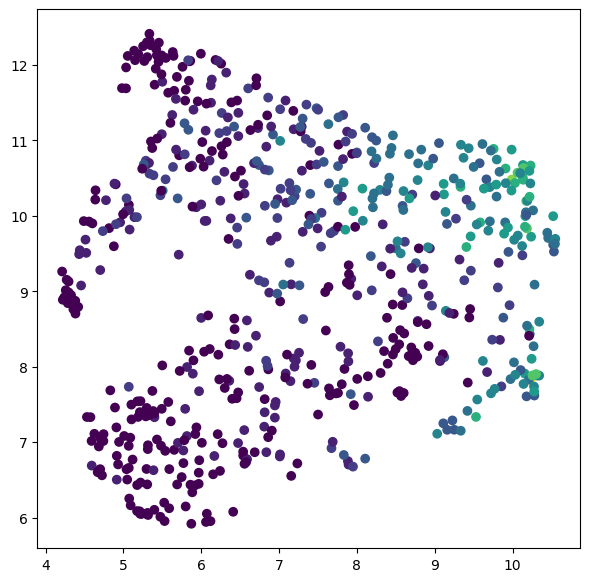

27


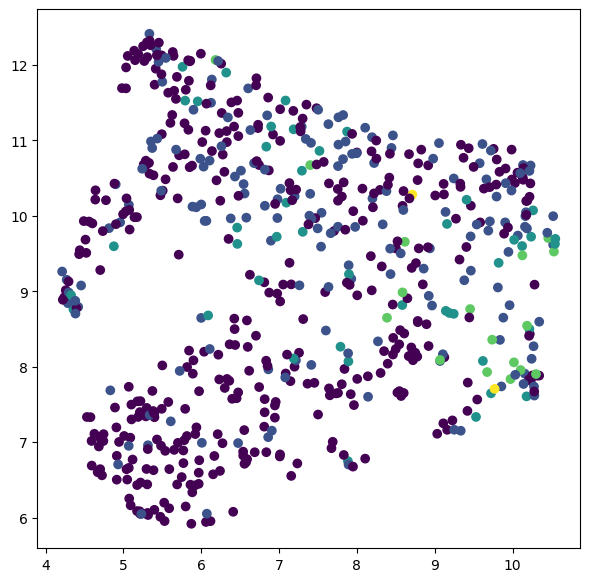

28


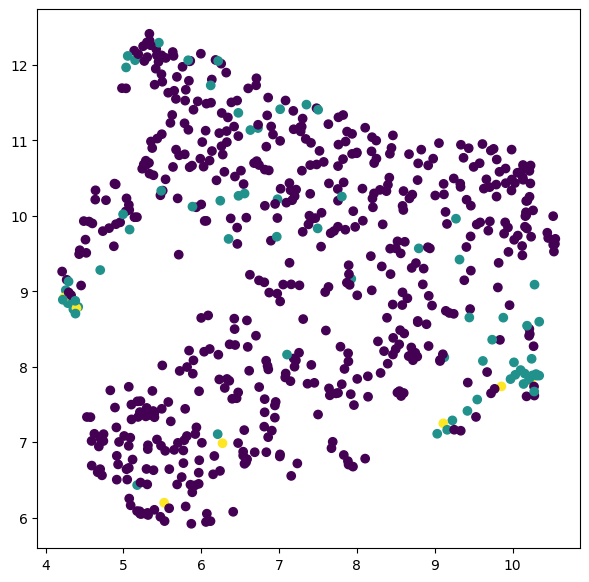

29


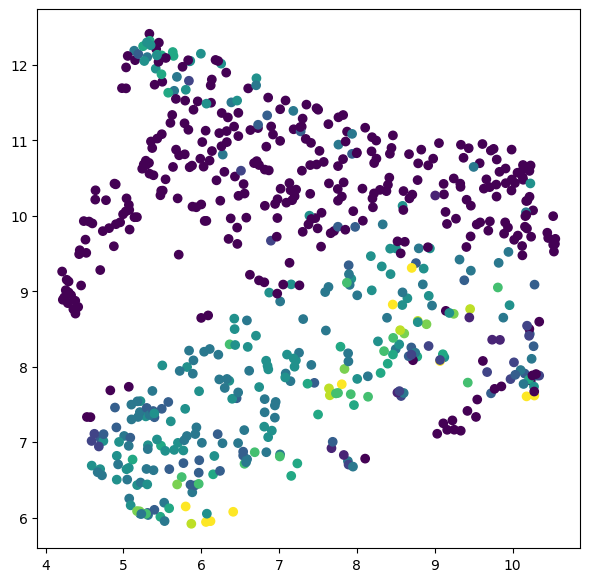

30


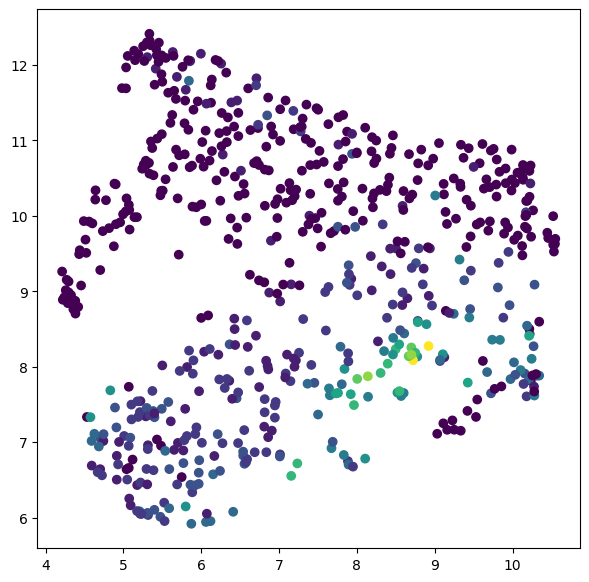

31


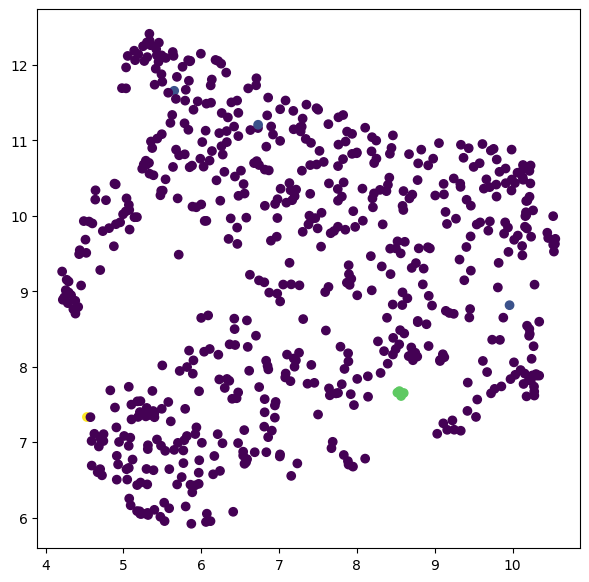

32


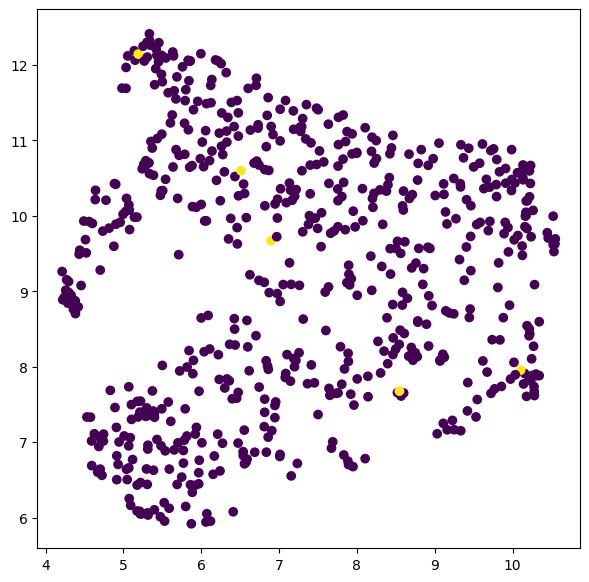

33


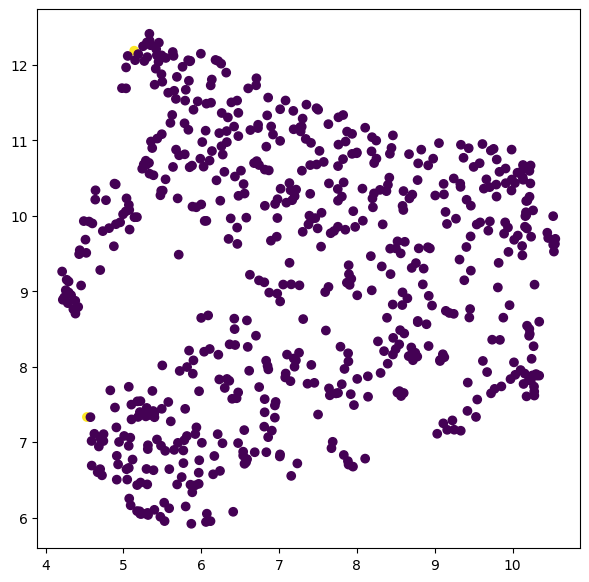

34


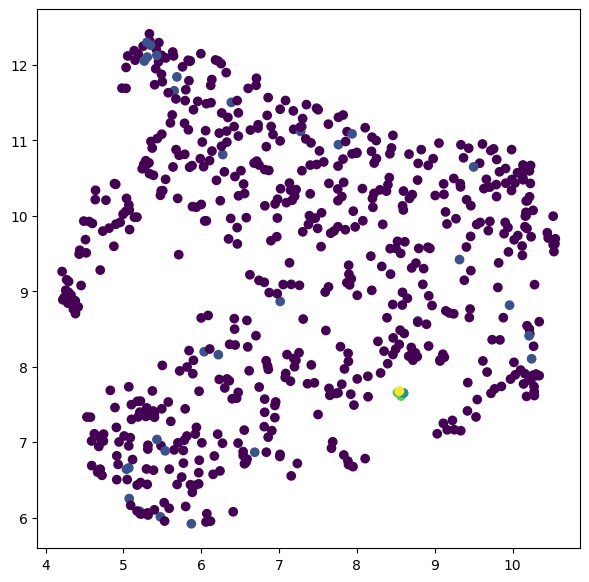

35


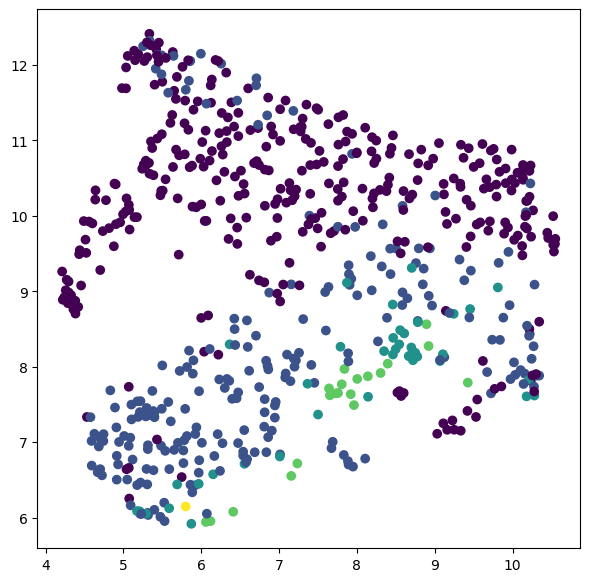

36


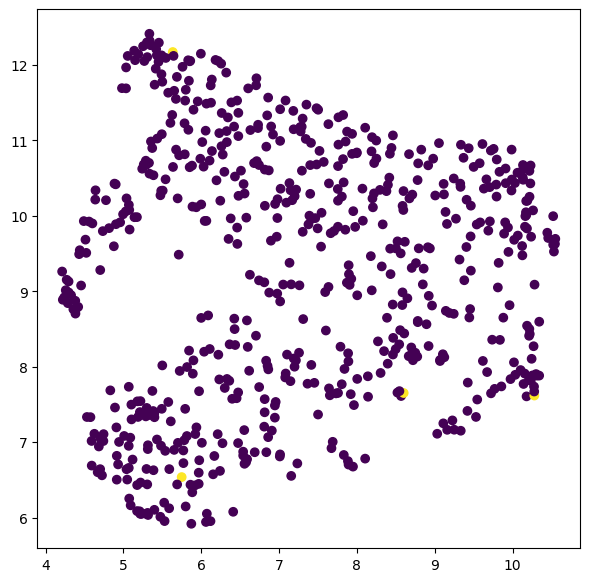

37


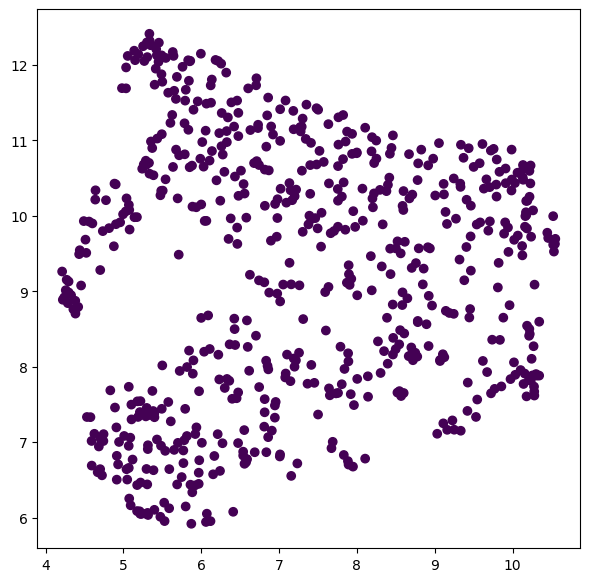

38


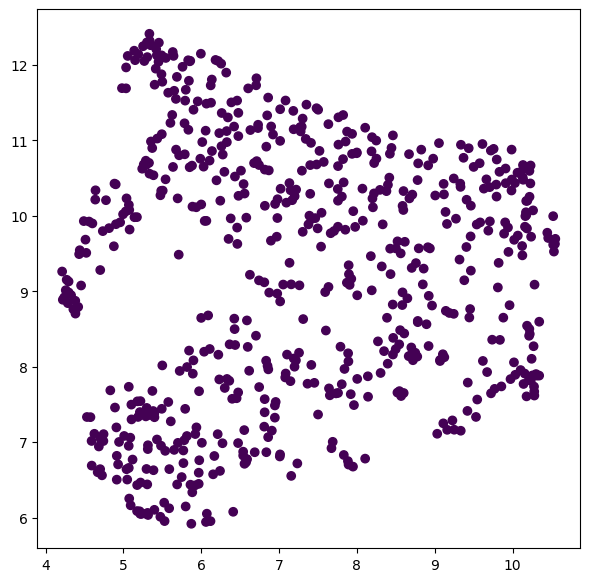

39


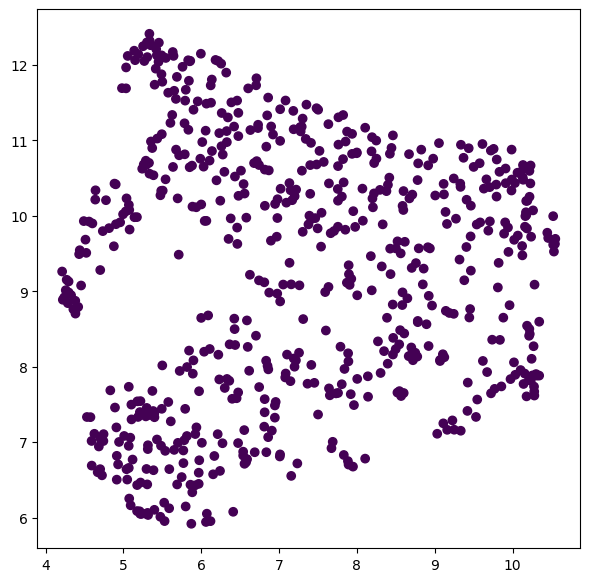

40


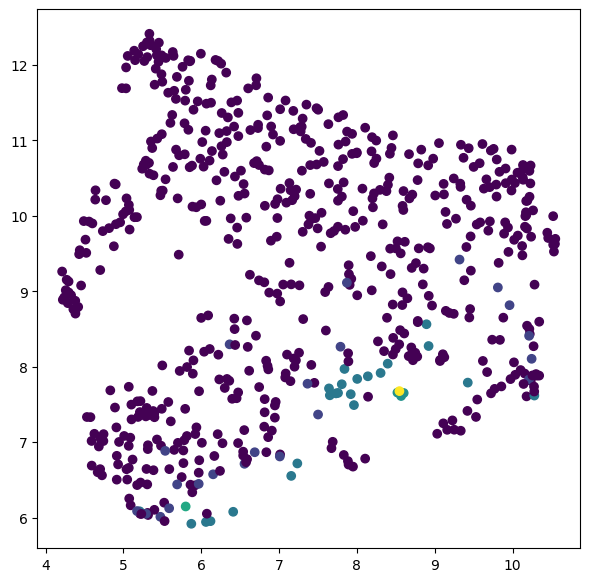

41


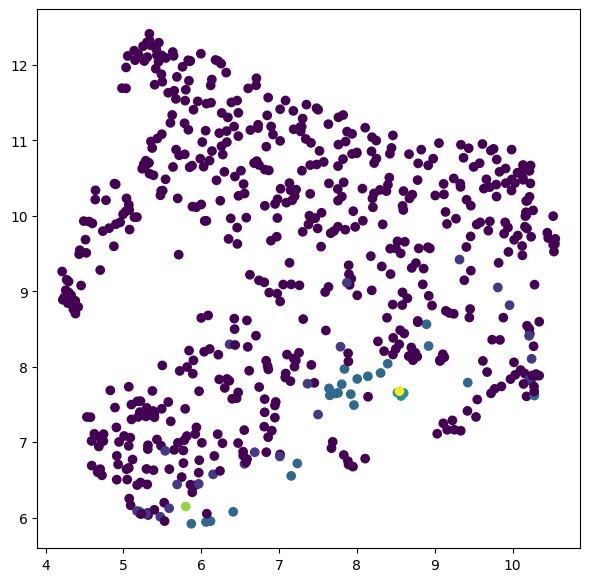

In [10]:
x_proj = umap.UMAP(n_neighbors=22).fit_transform(np.array(x))

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(x_proj.T[0], x_proj.T[1], c=y)
plt.show()

for i in range(42):
    y = []
    print(i)
    for smi in df["smiles"].tolist():
        mol = Chem.MolFromSmiles(smi)
        y.append(rdMolDescriptors.MQNs_(mol)[i])

    fig, ax = plt.subplots(figsize=(7, 7))
    
    ax.scatter(x_proj.T[0], x_proj.T[1], c=y)
    plt.show()